# Категориальные группировки и агрегации данных об отливках в управлении качеством

**Авторы:** И. П. Фрелих, В. Г. Мосин  
**Организация:** Самарский государственный технический университет (СамГТУ)  

В исследовании рассматривается выявление скрытых источников дефектов литья деталей в автомобилестроении на основе категориальных группировок, комбинаторных агрегаций и анализа технологических режимов.

Подробно об этом исследовании см. [полный текст статьи](paper.pdf).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("Библиотеки успешно импортированы.")

Библиотеки успешно импортированы.


## 1. Загрузка и первичный анализ данных

In [2]:
df = pd.read_csv('data/data.csv')
print(f"Размерность датасета: {df.shape[0]} отливок, {df.shape[1]} параметров")
print(f"Базовый уровень брака по выборке: {df['is_defect'].mean():.2%}")
df.head(5)

Размерность датасета: 5000 отливок, 18 параметров
Базовый уровень брака по выборке: 8.56%


,casting_id,date,shift,mold_id,melting_id,batch_code,pour_temperature_c,cooling_rate_k_per_min,holding_time_min,gas_content_ppm,weight_kg,hardness_hb,avg_dimension_mm,porosity_pores_per_cm2,ultrasonic_signal_db,is_defect,defect_type,time_of_day
0,1158,2025-01-02 04:24:35.092648800,3,12,11,B011,1456.692417,2.653179,15.365537,7.594077,11.903039,219.566779,0.017466,0.611412,-33.769698,0,none,4.400000
1,1837,2025-01-02 06:32:35.462349599,3,3,32,B032,1443.346248,2.384359,11.976305,8.066924,12.116231,205.559838,-0.147242,0.386155,-38.401044,0,none,6.533333
2,3503,2025-01-02 09:44:51.071406000,2,1,2,B002,1465.708315,2.992417,18.328174,8.346781,12.165713,232.143878,-0.027762,0.643643,-36.933670,0,none,9.733333
3,3151,2025-01-02 17:37:24.410128800,1,7,34,B034,1460.228272,4.365337,12.795539,8.226425,11.453692,245.082438,-0.198421,0.367596,-37.290483,1,crack,17.616667
4,4642,2025-01-02 22:00:28.118869200,1,10,19,B019,1461.806068,2.713199,14.436928,5.448211,11.878909,217.091245,-0.200748,0.341737,-38.119765,0,none,22.000000


## 2. Однофакторный анализ (Single-Factor Analysis)

In [3]:
# Доля брака по сменам
shift_stat = df.groupby('shift')['is_defect'].agg(['count', 'sum', 'mean']).reset_index()
shift_stat.columns = ['Смена', 'Всего_отливок', 'Брак_шт', 'Доля_брака']
shift_stat['Доля_брака_%'] = (shift_stat['Доля_брака'] * 100).round(2)
display(shift_stat)

# Доля брака по пресс-формам
mold_stat = df.groupby('mold_id')['is_defect'].agg(['count', 'sum', 'mean']).reset_index()
mold_stat.columns = ['Пресс_форма', 'Всего_отливок', 'Брак_шт', 'Доля_брака']
mold_stat['Доля_брака_%'] = (mold_stat['Доля_брака'] * 100).round(2)
display(mold_stat.sort_values('Доля_брака', ascending=False).head(5))

,Смена,Всего_отливок,Брак_шт,Доля_брака,Доля_брака_%
0,1,1671,149,0.089168,8.92
1,2,1716,128,0.074592,7.46
2,3,1613,151,0.093614,9.36


,Пресс_форма,Всего_отливок,Брак_шт,Доля_брака,Доля_брака_%
8,9,458,64,0.139738,13.97
6,7,420,42,0.100000,10.00
2,3,431,40,0.092807,9.28
7,8,407,36,0.088452,8.85
10,11,375,33,0.088000,8.80


## 3. Двухфакторный анализ: Смена × Пресс-форма

Построение матрицы сопряженности и расчет вероятности дефекта для каждой пары.

In [4]:
crosstab_rate = pd.crosstab(df['mold_id'], df['shift'], values=df['is_defect'], aggfunc='mean') * 100
crosstab_count = pd.crosstab(df['mold_id'], df['shift'], values=df['is_defect'], aggfunc='count')

print("Матрица доли брака (%):")
display(crosstab_rate.round(2))

prob_rate = crosstab_rate.loc[9, 3]
print(f"\nКРИТИЧЕСКАЯ ТОЧКА: Пресс-форма №9 в Смену 3 демонстрирует брак {prob_rate:.2f}% (при заводском {df['is_defect'].mean()*100:.2f}%)!")

Матрица доли брака (%):


shift,1,2,3
mold_id,,,
1,7.09,9.59,7.06
2,12.20,6.72,6.67
3,10.83,7.84,9.09
4,5.04,8.70,6.90
5,7.59,3.73,8.67
6,7.80,9.24,7.69
7,12.18,8.63,8.80
8,8.13,8.78,9.56
9,11.43,7.10,24.16



КРИТИЧЕСКАЯ ТОЧКА: Пресс-форма №9 в Смену 3 демонстрирует брак 24.16% (при заводском 8.56%)!


## 4. Сравнение технологических параметров проблемной группы

Сравнение средних значений и расчет величины эффекта Коэна (Cohen's d).

In [5]:
df['is_problem_group'] = ((df['shift'] == 3) & (df['mold_id'] == 9))

features = ['pour_temperature_c', 'cooling_rate_k_per_min', 'holding_time_min', 'gas_content_ppm']
names = ['Температура заливки (°C)', 'Скорость охлаждения (K/мин)', 'Время выдержки (мин)', 'Газосодержание (ppm)']

records = []
for feat, name in zip(features, names):
    g1 = df[df['is_problem_group']][feat]
    g0 = df[~df['is_problem_group']][feat]
    
    m1, m0 = g1.mean(), g0.mean()
    s1, s0 = g1.std(), g0.std()
    
    # Cohen's d
    s_pooled = np.sqrt(((len(g1)-1)*s1**2 + (len(g0)-1)*s0**2) / (len(g1) + len(g0) - 2))
    cohen_d = (m1 - m0) / s_pooled
    
    # Welch t-test
    stat, pval = stats.ttest_ind(g1, g0, equal_var=False)
    
    records.append({
        'Параметр': name,
        'Проблемная (Смена 3 x Форма 9)': round(m1, 2),
        'Остальное производство': round(m0, 2),
        'Разница (%)': f"{(m1-m0)/m0*100:+.2f}%",
        "Cohen's d": round(cohen_d, 2),
        'p-value': f"{pval:.2e}"
    })

res_df = pd.DataFrame(records)
display(res_df)

,Параметр,Проблемная (Смена 3 x Форма 9),Остальное производство,Разница (%),Cohen's d,p-value
0,Температура заливки (°C),1463.97,1450.32,+0.94%,1.30,3.98e-38
1,Скорость охлаждения (K/мин),1.50,2.54,-40.93%,-1.29,5.47e-33
2,Время выдержки (мин),20.19,14.98,+34.75%,2.52,4.88e-64
3,Газосодержание (ppm),9.96,7.99,+24.57%,1.33,2.38e-33


## 5. Графическая визуализация синергетического брака

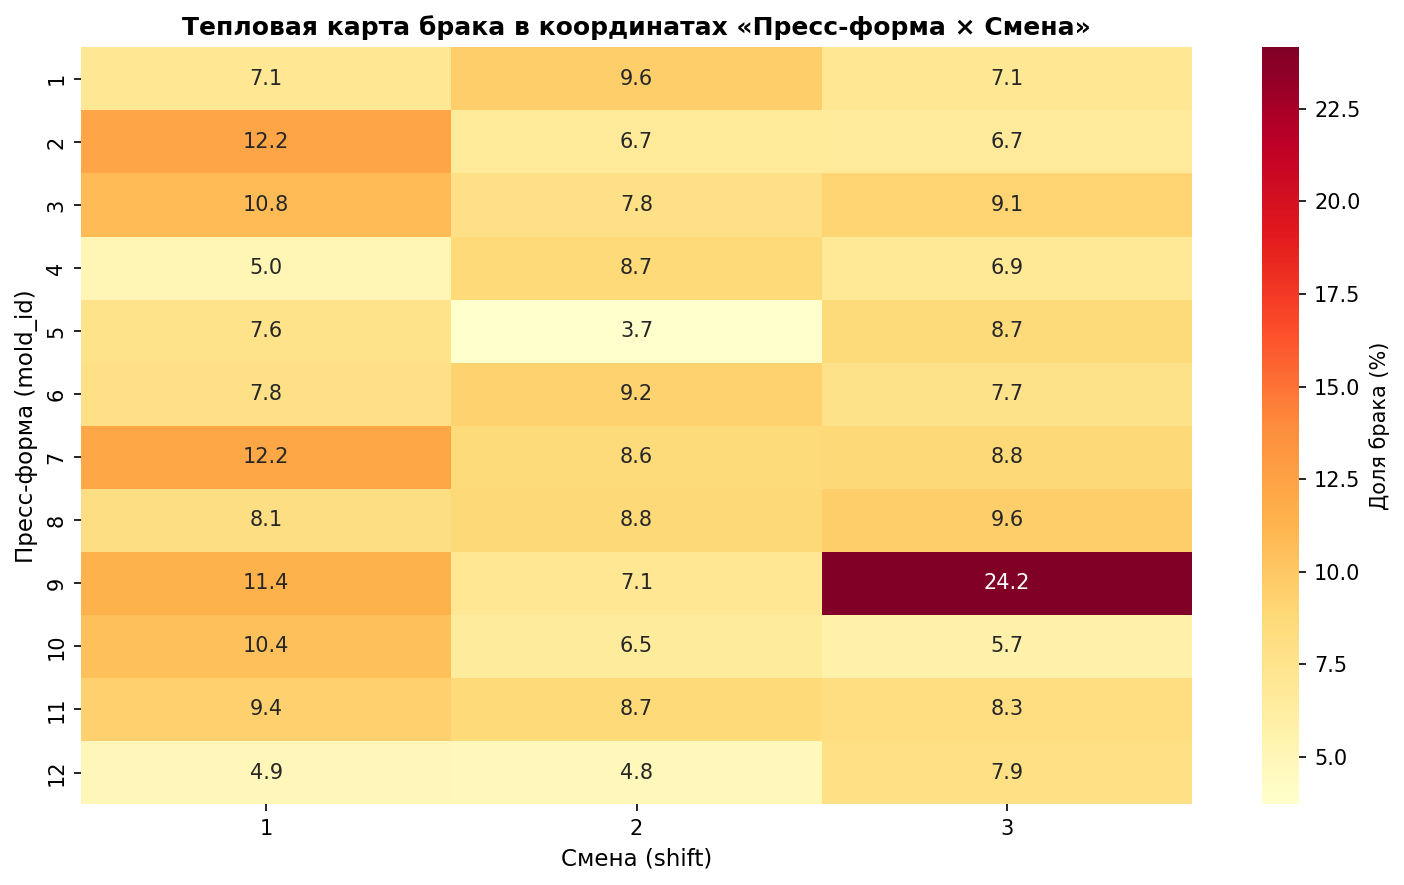

In [6]:
plt.figure(figsize=(10, 6), dpi=150)
sns.heatmap(crosstab_rate, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Доля брака (%)'})
plt.title('Тепловая карта брака в координатах «Пресс-форма × Смена»', fontsize=12, fontweight='bold')
plt.xlabel('Смена (shift)', fontsize=11)
plt.ylabel('Пресс-форма (mold_id)', fontsize=11)
plt.tight_layout()
plt.show()